# Owen and Picogna flux tests comparison

This notebook reproduces the side-by-side comparison figure for the two photoevaporation models used in the paper.
The inputs are the saved surface mass-loss profiles and the plotting is done in CGS units for direct physical comparison.


In [5]:
import subprocess
import os

# ensure we run from project root if notebook is inside "notebooks"
cwd = os.getcwd()
if os.path.basename(cwd) == "notebooks":
    os.chdir("..")

yaml_files = [
    "notebooks/configs/owen_photoevaporation_flux_test.yaml",
    "notebooks/configs/picogna_photoevaporation_flux_test.yaml"
]

for yaml_path in yaml_files:
    print("\n==============================================")
    print(f"Running simulation for: {yaml_path}")
    print("==============================================\n")

    cmd = [
        "python3",
        "run_simulation.py",
        "--config",
        yaml_path
    ]

    process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

    for line in process.stdout:
        print(line.rstrip("\n"))

    process.wait()

    print(f"\nSimulation finished for: {yaml_path}\n")



Running simulation for: notebooks/configs/owen_photoevaporation_flux_test.yaml

[PY-WRAPPER] Terminal panels disabled (YAML setting).

[PY-WRAPPER] --- Running: Main Simulation Program ---
[PY-WRAPPER] The current command-line arguments are:
 ./bin/simulation -v -no_panels -evol 1.0 -test photoevap_flux -n 512 -grid_type logarithmic -ri 1.0 -ro 300.0 -sigma0_init 1e-5 -index_init -1 -alpha_init 0.0001 -stellar_mass 0.7 -h_init 0.05 -flind_init 0.0 -photoevap_mode Owen -xray_luminosity 2.0e30 -density_floor 1e-20 -inner_bc zero_gradient -outer_bc zero_gradient -o notebooks/photoevaporation_test/photoevaporation_owen -tmax 1e6 -outfreq 50000
[PY-WRAPPER] Setting OMP_NUM_THREADS=1 for this run.
[PY-WRAPPER] Start running the binary (./bin/simulation) at 2026-09-24 02:12:23...

||                                                                      ||
||                        RAPID SIMULATION CORE                         ||
||                            Version: 2.2.4                    

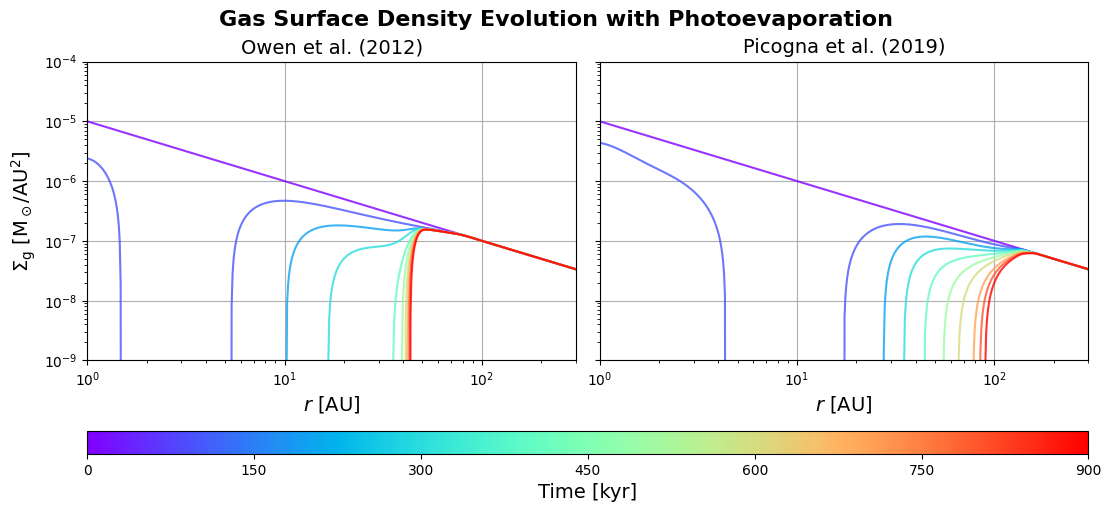

Saved figure to: photoevaporation_owen_vs_picogna.png


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import FuncFormatter, MaxNLocator
import glob
import os

MSUN_G = 1.98847e33
AU_CM = 1.495978707e13
SURFACE_DENSITY_TO_CGS = MSUN_G / AU_CM**2
PROFILE_INTERVAL_YEARS = 100_000

# --- Benchmark log directories ---
benchmark_dirs = {
    "Owen et al. (2012)": "notebooks/photoevaporation_test/photoevaporation_owen/LOGS",
    "Picogna et al. (2019)": "notebooks/photoevaporation_test/photoevaporation_picogna/LOGS",
}


def load_selected_profiles(base_dir):
    profiles = []
    sigma_files = sorted(glob.glob(os.path.join(base_dir, "sigma_profile_t_*.dat")))

    for fname in sigma_files:
        t_str = fname.split("_t_")[1].split(".")[0]
        t_val = float(t_str)
        if int(round(t_val)) % PROFILE_INTERVAL_YEARS != 0:
            continue

        data = np.loadtxt(fname)
        radius = data[:, 0]
        sigma = data[:, 1]
        profiles.append((radius, sigma, t_val))

    return profiles


# --- Plot Owen and Picogna side by side ---
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True,
                         constrained_layout=True)
all_profile_times = []

for base_dir in benchmark_dirs.values():
    all_profile_times.extend(
        profile[2] for profile in load_selected_profiles(base_dir)
    )

time_norm = Normalize(vmin=min(all_profile_times), vmax=max(all_profile_times))
color_map = plt.get_cmap("rainbow")

for axis, (model_name, base_dir) in zip(axes, benchmark_dirs.items()):
    selected_profiles = load_selected_profiles(base_dir)

    for radius, sigma, t_val in selected_profiles:
        axis.plot(radius, sigma, color=color_map(time_norm(t_val)),
                  alpha=0.8)

    axis.set_xlabel(r"$r$ [AU]", fontsize=14)
    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set_title(model_name, fontsize=14)
    axis.set_ylim(1e-9, 1e-4)
    axis.set_xlim(1, 300)
    axis.grid(True)

axes[0].set_ylabel(f"$\Sigma_{{\\rm g}}$ [M$_\odot$/AU$^2$]", fontsize=14)
fig.suptitle("Gas Surface Density Evolution with Photoevaporation", fontweight="bold", fontsize=16)
color_bar = ScalarMappable(norm=time_norm, cmap=color_map)
color_bar.set_array([])
colorbar = fig.colorbar(color_bar, ax=axes, orientation="horizontal",
                        pad=0.05, fraction=0.08, aspect=45)
colorbar.set_label("Time [kyr]", fontsize=14)
colorbar.ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
colorbar.ax.xaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"{value / 1000:g}")
)

# --- Save the comparison figure ---
outpath = "photoevaporation_owen_vs_picogna.png"
plt.savefig(outpath, dpi=200)

plt.show()

print(f"Saved figure to: {outpath}")


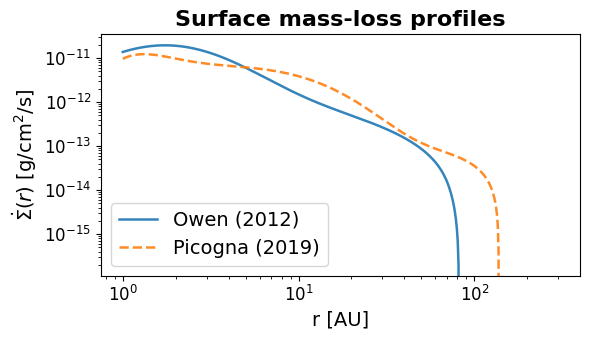

Saved CGS Owen/Picogna plot to: photoevap_flux_profiles_CGS_owen_vs_picogna.png


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from matplotlib.lines import Line2D

SUN2GR = 1.989e33
AU2CM = 1.496e13
YEAR2SEC = 365.25 * 86400.0


def code_to_cgs(sigma_dot):
    """Convert M_sun/AU^2/year to g/cm^2/s for plotting only."""
    return sigma_dot * SUN2GR / AU2CM**2 / YEAR2SEC


benchmark_dirs = {
    "Owen": "notebooks/photoevaporation_test/photoevaporation_owen/LOGS",
    "Picogna": "notebooks/photoevaporation_test/photoevaporation_picogna/LOGS",
}

profiles = {}

for model_name, base_dir in benchmark_dirs.items():
    model_profiles = {}
    dot_files = sorted(glob.glob(os.path.join(base_dir, "sigma_dot_profile_t_*.dat")))

    for fname in dot_files:
        t_str = fname.split("_t_")[1].split(".")[0]
        t_val = float(t_str)
        data = np.loadtxt(fname)
        radius = data[:, 0]
        sigma_dot_code = data[:, 1]   # Msun/AU^2/year
        model_profiles[t_val] = (radius, code_to_cgs(sigma_dot_code))

    profiles[model_name] = model_profiles


# --- Plot in CGS units; simulation output remains in native units ---
plt.figure(figsize=(6, 3.5))
for model_name, linestyle in [("Owen (2012)", "-"), ("Picogna (2019)", "--")]:
    if profiles[model_name.replace(" (2012)", "").replace(" (2019)", "")]:
        initial_time = min(profiles[model_name.replace(" (2012)", "").replace(" (2019)", "")])
        radius, sigma_dot_cgs = profiles[model_name.replace(" (2012)", "").replace(" (2019)", "")][initial_time]
        plt.plot(radius, sigma_dot_cgs, linestyle=linestyle,
                 linewidth=1.8, alpha=0.9,
                 label=f"{model_name}")

plt.xlabel("r [AU]", fontsize=14)
plt.ylabel(r"$\dot{\Sigma}(r)$ [g/cm$^2$/s]", fontsize=14)
plt.yscale("log")
plt.xscale("log")
plt.tick_params(axis='both', which='major', labelsize=12)
plt.title("Surface mass-loss profiles", fontweight="bold", fontsize=16)
plt.legend(loc="lower left", fontsize=14)
plt.tight_layout()

outpath = "photoevap_flux_profiles_CGS_owen_vs_picogna.png"
output_dir = os.path.dirname(outpath)
if output_dir:
    os.makedirs(output_dir, exist_ok=True)
plt.savefig(outpath, dpi=300)
plt.show()

print(f"Saved CGS Owen/Picogna plot to: {outpath}")
